In [8]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [9]:
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = ""   # clear any xla flags
import tensorflow as tf
tf.config.optimizer.set_jit(False)


2026-04-05 17:18:01.760512: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 17:18:02.908320: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 17:18:08.977814: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
import numpy as np
# import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


In [11]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.feature_selection import VarianceThreshold

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

In [12]:
columns= [
    'patientunitstayid','gender','age','bmi',
    'nurse_first_Non-Invasive BP Systolic',
    'nurse_first_Non-Invasive BP Diastolic',
    'nurse_first_Non-Invasive BP Mean',
    'nurse_first_Heart Rate',
    'nurse_first_O2 Saturation',
    'nurse_first_Temperature (C)',
    'lab_first_Respiratory Rate',
    'lab_first_FiO2',
    'nurse_first_GCS Total',
    'nurse_first_Motor','FirstGCS','LastGCS','LastGCS15',
    'nurse_first_QTc',
    'lab_first_pH','lab_first_paO2','lab_first_paCO2',
    'lab_first_bicarbonate','lab_first_lactate',
    'lab_first_WBC x 1000','lab_first_Hgb','lab_first_platelets x 1000',
    'lab_first_sodium','lab_first_potassium','lab_first_BUN',
    'lab_first_creatinine','lab_first_calcium','lab_first_magnesium',
    'lab_first_glucose','lab_first_troponin - I','lab_first_troponin - T',
    'diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_ventricular fibrillation',
    'diagnosis_ventricular tachycardia',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole',
    # 'FirstMGCS',
    # 'hypothermia_time',
    'Hypothermia',
]


In [13]:
# import re
# import pandas as pd
# from difflib import SequenceMatcher

# # ---------------------------------------------------
# # 1) all pasted columns as targets
# # ---------------------------------------------------
# target_columns = [
#     'SUBJID',
#     'groupe',
#     'CPC_SC3',
#     'J0_SEX',
#     'J0_TAILLE',
#     'J0_POIDS',
#     'J0_BMI',
#     'J0_AGE',
#     'J0_PAS',
#     'J0_PAD',
#     'J0_PAM',
#     'J0_FC',
#     'J0_SPO2',
#     'J0_GLASGOW',
#     'J0_GLASGOW_CONTROLE',
#     'J0_OCULAIRE',
#     'J0_VERBALE',
#     'J0_MOTRICE',
#     'J0_PUPILG',
#     'J0_PUPILG_REA',
#     'J0_PUPILD',
#     'J0_PUPILD_REA',
#     'J0_CILIAIRE',
#     'J0_CORNEEN',
#     'J0_REFLEXVEST',
#     'J0_REFLEXCEPH',
#     'J0_REFLEXCARD',
#     'J0_TEMP',
#     'J0_IGSII',
#     'J0_MCCABE',
#     'J0_KNAUS',
#     'J0_CHARLSON1',
#     'J0_CHARLSON2',
#     'J0_CHARLSON3',
#     'J0_CHARLSON4',
#     'J0_CHARLSON5',
#     'J0_CHARLSON6',
#     'J0_CHARLSON7',
#     'J0_CHARLSON8',
#     'J0_CHARLSON9',
#     'J0_CHARLSON10',
#     'J0_CHARLSON11',
#     'J0_CHARLSON12',
#     'J0_CHARLSON13',
#     'J0_CHARLSON14',
#     'V0_CHARLSON15',
#     'V0_CHARLSON16',
#     'V0_CHARLSON17',
#     'V0_CHARLSON18',
#     'V0_CHARLSON18B',
#     'V0_CHARLSON19',
#     'J0_CHARLSON',
#     'J0_ATCD',
#     'J0_CARDIO',
#     'J0_NYHA',
#     'J0_MYOCARD',
#     'J0_ARTERIO',
#     'J0_HTA',
#     'J0_POUMON',
#     'J0_IRC',
#     'J0_HYPERCAP',
#     'J0_O2',
#     'J0_TABAC',
#     'J0_RYTHM',
#     'J0_CAUSE2_ACR',
#     'J0_DSA',
#     'J0_DSA_P',
#     'J0_TEMOIN',
#     'J0_TEMOIN_MASSE',
#     'J0_LIEU_ACR',
#     'J0_NOFLOW',
#     'J0_LOWFLOW',
#     'J0_ADRE',
#     'J0_ADRE_DOS',
#     'J0_CORDA',
#     'J0_CORDA_DOS',
#     'J0_BICARB',
#     'J0_BICARB_DOS',
#     'V0_REFROIDI',
#     'V0_CHOC_AV',
#     'V0_CHOC_AP',
#     'V0_PLANCHE',
#     'V0_THROMBO',
#     'V0_CORO_ACR',
#     'V0_ANGIO_ACR',
#     'V0_ANGIO_YES',
#     'V0_BALLON',
#     'V0_ACR2',
#     'J0_CURAR',
#     'J0_SEDATIF',
#     'J0_MORPHIN',
#     'J0_COAGUL',
#     'J0_AGREG',
#     'J0_ANTIBIO',
#     'J0_AMINE',
#     'J0_NORA',
#     'J0_ADRE2',
#     'J0_DOBU',
#     'J0_DOPA',
#     'J0_PEP',
#     'J0_FIO2',
#     'J0_VT',
#     'J0_FR',
#     'BIO_LEUCO',
#     'BIO_HEMO',
#     'BIO_PLAQ',
#     'BIO_TP',
#     'BIO_DDIMERE',
#     'BIO_SODIUM',
#     'BIO_POTAS',
#     'BIO_UREE',
#     'BIO_CREAT',
#     'BIO_CALCIUM',
#     'BIO_MAGNE',
#     'BIO_GLYCEMI',
#     'BIO_PROTID',
#     'BIO_LIPAS',
#     'BIO_TROPO',
#     'BIO_TEMP',
#     'BIO_FIO2',
#     'BIO_PH',
#     'BIO_PAO2',
#     'BIO_PACO2',
#     'BIO_BICARB',
#     'BIO_LACTAT',
#     'BIO_TROPO2',
#     'BIO_TROPO_CGT',
#     'ECG',
#     'ECG_QTC',
#     'ECG_ANOMALI',
#     'ECG_SUS_ST',
#     'ECG_SOUS_ST',
#     'ECG_BAVI',
#     'ECG_BAVII',
#     'ECG_BAVIII',
#     'ECG_BBG',
#     'ECG_BBD',
#     'ECG_TACHICARD',
#     'ECG_FIBRIL',
#     'ECG_SALV_VENT',
#     'ECG_FLUTER',
#     'ECG_SALV_SUPRA',
#     'SOFA_SC',
#     'SOFA_RESPIR',
#     'SOFA_CARDIO',
#     'SOFA_COAG',
#     'SOFA_NEURO',
#     'SOFA_FOIE',
#     'SOFA_RENAL',
#     'EI_EI',
#     'EI_HEMOSEVER',
#     'EI_TRANSFUS',
#     'EI_INTRACER',
#     'EI_CHIR',
#     'EI_EXTRARENAL',
#     'EI_OAP',
#     'EI_ECHO',
#     'EI_DIURETIQ',
#     'EI_CONVULS',
#     'EI_ARYTHMI',
#     'EI_ANTIEPILEPTIQ',
#     'BARTHEL_SC',
#     'SOFA_SC7',
#     'SOFA_SC1',
#     'DS_DC',
#     'DAYS_ALIVE_30',
#     'CPC12',
#     'SEX'
# ]

# # ---------------------------------------------------
# # 2) normalize names for better matching
# # ---------------------------------------------------
# def normalize_col(s: str) -> str:
#     s = str(s).lower().replace('_', ' ')

#     replacements = {
#         'subjid': 'subject patient id',
#         'groupe': 'group treatment arm',
#         'taille': 'height',
#         'poids': 'weight',
#         'bmi': 'body mass index',
#         'age': 'age',
#         'pas': 'systolic blood pressure sbp',
#         'pad': 'diastolic blood pressure dbp',
#         'pam': 'mean arterial pressure map',
#         'fc': 'heart rate pulse',
#         'spo2': 'oxygen saturation spo2',
#         'glasgow': 'glasgow coma scale gcs',
#         'oculaire': 'eye ocular',
#         'verbale': 'verbal',
#         'motrice': 'motor',
#         'pupilg': 'left pupil',
#         'pupild': 'right pupil',
#         'rea': 'reactive reactivity',
#         'ciliaire': 'ciliary reflex',
#         'corneen': 'corneal reflex',
#         'reflexvest': 'vestibular reflex',
#         'reflexceph': 'cephalic reflex',
#         'reflexcard': 'cardiac reflex',
#         'igsii': 'saps ii severity score',
#         'mccabe': 'mccabe score',
#         'knaus': 'knaus apache chronic health',
#         'atcd': 'past medical history comorbidity',
#         'cardio': 'cardiovascular history',
#         'nyha': 'nyha heart failure class',
#         'myocard': 'myocardial infarction',
#         'arterio': 'peripheral arterial disease vascular disease',
#         'hta': 'hypertension',
#         'poumon': 'lung pulmonary disease',
#         'irc': 'chronic kidney disease renal insufficiency',
#         'hypercap': 'hypercapnia',
#         'o2': 'oxygen therapy oxygen',
#         'tabac': 'smoking tobacco',
#         'rythm': 'rhythm arrest rhythm',
#         'cause2 acr': 'cardiac arrest cause',
#         'dsa': 'defibrillation shock',
#         'temoin': 'witnessed witnessed arrest',
#         'lieu acr': 'cardiac arrest location',
#         'noflow': 'no flow',
#         'lowflow': 'low flow',
#         'adre': 'epinephrine adrenaline',
#         'corda': 'cordarone amiodarone',
#         'bicarb': 'bicarbonate',
#         'refroidi': 'cooling hypothermia targeted temperature management ttm',
#         'choc': 'shock',
#         'planch': 'board',
#         'thrombo': 'thrombolysis thrombosis',
#         'coro acr': 'coronary angiography arrest',
#         'angio': 'angiography',
#         'ballon': 'balloon pump',
#         'curar': 'neuromuscular blocker paralysis',
#         'sedatif': 'sedation sedative',
#         'morphin': 'morphine opioid',
#         'coagul': 'anticoagulation coagulopathy',
#         'agreg': 'antiplatelet aggregation',
#         'antibio': 'antibiotic',
#         'amine': 'vasopressor amine',
#         'nora': 'norepinephrine noradrenaline',
#         'dobu': 'dobutamine',
#         'dopa': 'dopamine',
#         'pep': 'peep positive end expiratory pressure',
#         'fio2': 'fraction inspired oxygen fio2',
#         'vt': 'tidal volume vt ventricular tachycardia',
#         'fr': 'respiratory rate',
#         'leuco': 'white blood cell wbc leukocyte',
#         'hemo': 'hemoglobin hgb',
#         'plaq': 'platelets platelet count',
#         'tp': 'prothrombin time pt',
#         'ddimere': 'd dimer',
#         'uree': 'urea bun blood urea nitrogen',
#         'creat': 'creatinine',
#         'magne': 'magnesium',
#         'glycemi': 'glucose glycemia',
#         'protid': 'protein total protein',
#         'lipas': 'lipase',
#         'tropo': 'troponin',
#         'ph': 'ph',
#         'pao2': 'arterial oxygen pao2',
#         'paco2': 'arterial carbon dioxide paco2',
#         'lactat': 'lactate',
#         'qtc': 'qt corrected qtc',
#         'anomali': 'abnormality',
#         'sus st': 'st elevation',
#         'sous st': 'st depression',
#         'bavi': 'av block first degree',
#         'bavii': 'av block second degree',
#         'baviii': 'av block third degree',
#         'bbg': 'left bundle branch block',
#         'bbd': 'right bundle branch block',
#         'tachicard': 'tachycardia',
#         'fibril': 'fibrillation',
#         'salv vent': 'ventricular tachycardia ventricular run',
#         'fluter': 'flutter',
#         'salv supra': 'supraventricular run',
#         'respir': 'respiratory',
#         'cardio': 'cardiovascular cardiac',
#         'coag': 'coagulation',
#         'neuro': 'neurologic neurological',
#         'foie': 'liver hepatic',
#         'renal': 'renal kidney',
#         'hemosever': 'severe bleeding hemorrhage',
#         'transfus': 'transfusion',
#         'intracer': 'intracerebral intracranial',
#         'chir': 'surgery surgical',
#         'oap': 'pulmonary edema',
#         'echo': 'echocardiography echo',
#         'diuretiq': 'diuretic',
#         'convuls': 'seizure convulsion',
#         'arythmi': 'arrhythmia',
#         'antiepileptiq': 'antiepileptic',
#         'barthel': 'barthel functional status',
#         'dc': 'death deceased',
#         'days alive 30': 'days alive at 30 days',
#         'cpc': 'cerebral performance category'
#     }

#     for old, new in replacements.items():
#         s = s.replace(old, new)

#     s = re.sub(r'[^a-z0-9]+', ' ', s)
#     s = re.sub(r'\s+', ' ', s).strip()
#     return s

# def similarity(a: str, b: str) -> float:
#     return SequenceMatcher(None, a, b).ratio()

# # ---------------------------------------------------
# # 3) score each target against all columns in df_other
# # ---------------------------------------------------
# def score_target_against_columns(target_col, candidate_columns, top_n=2):
#     norm_target = normalize_col(target_col)
#     target_tokens = set(norm_target.split())

#     rows = []
#     for col in candidate_columns:
#         norm_col = normalize_col(col)
#         col_tokens = set(norm_col.split())

#         score = similarity(norm_target, norm_col)

#         if norm_target == norm_col:
#             score += 1.0
#         elif norm_target in norm_col or norm_col in norm_target:
#             score += 0.35

#         if len(target_tokens) > 0:
#             overlap = len(target_tokens & col_tokens) / len(target_tokens)
#             score += 0.5 * overlap

#         rows.append({
#             'target_column': target_col,
#             'candidate_column': col,
#             'score': score
#         })

#     return pd.DataFrame(rows).sort_values('score', ascending=False).head(top_n)

# def search_all_target_columns(df_other, target_columns=target_columns, top_n=2):
#     results = []
#     for target in target_columns:
#         results.append(score_target_against_columns(target, df_other.columns, top_n=top_n))
#     return pd.concat(results, ignore_index=True)

# # ---------------------------------------------------
# # 4) run it
# # ---------------------------------------------------
# # replace df_other with your other dataset
# columns2 = [x for x in myPredictorsDf.columns if '_min_' not in x.lower() and '_max_' not in x.lower() and '_last_' not in x.lower() and '_mean_' not in x.lower()]
# top2_matches = search_all_target_columns(myPredictorsDf[columns2], target_columns=target_columns, top_n=2)

# # tidy output
# top2_matches = top2_matches.sort_values(['target_column', 'score'], ascending=[True, False]).reset_index(drop=True)
# top2_matches

In [14]:
# columns = top2_matches.candidate_column.tolist()

In [15]:
columns += ['diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_ventricular fibrillation',
    'diagnosis_ventricular tachycardia',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole',
    'FirstMGCS',
    # 'hypothermia_time',

    'Hypothermia',]

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')
    # Preprocessing
    # print(myPredictorsDf['hypothermia_time'])
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) #& (myPredictorsDf['FirstMGCSTime'] < 360)
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.nurse_first_Motor != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myFilter & myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['FirstGCS',
                                                         'LastMGCSTime', 
                                                         'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 
                                                         'apacheadmissiondx', 'hospitaladmittime24', 
                                                         'FirstGCSTime', 'LastGCSTime', 'LastGCS', 
                                                         'hospitaldischargestatus', 
                                                         'LastGCS15', 'hospitaladmitsource', 
                                                         'DeathAtDischarge', 'patientunitstayid', 'hypothermia_time'])
    # myXValue = myXValue[columns]
    myXValue = myXValue
    # myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    # myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [17]:
myTreatmentColumn = 'Hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aDropColumns=[], 
                                                                         aSkipTemp = True) 

/local/mbranda1/3100884/ipykernel_89607/800145171.py:6: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [18]:
[x for x in X_train.columns if 'gcs' in x.lower()]
 

['nurse_first_GCS Total',
 'nurse_last_GCS Total',
 'nurse_max_GCS Total',
 'nurse_min_GCS Total',
 'nurse_mean_GCS Total',
 'FirstMGCS']

In [19]:
columns_filter = np.unique([x for x in columns if x in X_test.columns])

X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [20]:
X_train

,FirstMGCS,Hypothermia,age,bmi,diagnosis_initial rhythm: asystole,diagnosis_initial rhythm: pulseless electrical activity,diagnosis_initial rhythm: ventricular fibrillation,diagnosis_initial rhythm: ventricular tachycardia,diagnosis_ventricular fibrillation,diagnosis_ventricular tachycardia,...,lab_first_troponin - I,lab_first_troponin - T,nurse_first_GCS Total,nurse_first_Heart Rate,nurse_first_Motor,nurse_first_Non-Invasive BP Diastolic,nurse_first_Non-Invasive BP Mean,nurse_first_Non-Invasive BP Systolic,nurse_first_O2 Saturation,nurse_first_QTc
880,4.0,1.0,44,29.535031,0.0,0.0,1.0,0.0,0.0,0.0,...,0.070,NaN,6.0,95.0,4.0,104.0,97.0,120.0,87.0,NaN
708,1.0,0.0,81,35.047292,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,3.0,110.0,1.0,92.0,110.0,165.0,89.0,NaN
2910,1.0,0.0,26,25.812297,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,3.0,101.0,1.0,67.0,84.0,139.0,88.0,NaN
591,1.0,0.0,63,25.880571,0.0,0.0,0.0,0.0,0.0,0.0,...,0.090,NaN,3.0,105.0,1.0,36.0,39.0,70.0,67.0,NaN
226,4.0,0.0,82,17.702519,0.0,0.0,0.0,0.0,0.0,0.0,...,0.825,NaN,6.0,114.0,4.0,69.0,54.0,130.0,97.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2181,1.0,0.0,50,45.501378,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.45,3.0,89.0,1.0,68.0,83.0,107.0,94.0,NaN
2316,1.0,0.0,74,22.315721,0.0,0.0,0.0,0.0,0.0,0.0,...,3.340,NaN,3.0,113.0,1.0,45.0,35.0,77.0,86.0,NaN
2755,2.0,1.0,86,31.031695,NaN,NaN,NaN,NaN,NaN,NaN,...,0.390,NaN,4.0,79.0,2.0,62.0,84.0,134.0,97.0,NaN
2058,1.0,0.0,89,27.732526,0.0,0.0,0.0,0.0,0.0,0.0,...,0.220,NaN,3.0,79.0,1.0,88.0,108.0,130.0,100.0,NaN


In [2]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )
def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [3]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [4]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.5]
# X_test = X_test[X_train.columns]

In [21]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [22]:
X_train_transf.shape

(1289, 47)

In [23]:
[x for x in X_train_transf.columns if 'hyp'in x]

[]

In [24]:
import torch
import torch.nn as nn

class MLPBinary(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(32, 1)  # logits (no sigmoid here)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (batch,)


    @torch.no_grad()
    def predict_proba(self, X, device=None, batch_size=8192):
        """
        sklearn-style: returns shape (n, 2) = [P(class0), P(class1)]
        """
        self.eval()
        device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.to(device)

        # X can be numpy or pandas
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        X = np.asarray(X, dtype=np.float32)

        probs1 = []
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(device)
            logits = self(xb)
            p1 = torch.sigmoid(logits).detach().cpu().numpy()
            probs1.append(p1)

        p1 = np.concatenate(probs1, axis=0).reshape(-1)
        p0 = 1.0 - p1
        return np.stack([p0, p1], axis=1)

    @torch.no_grad()
    def predict(self, X, threshold=0.5, **kwargs):
        """
        sklearn-style: returns class labels (0/1)
        """
        proba = self.predict_proba(X, **kwargs)[:, 1]
        return (proba >= threshold).astype(int)


In [25]:
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score

def to_tensor(x):
    # works if x is numpy array or pandas dataframe
    if hasattr(x, "to_numpy"):
        x = x.to_numpy()
    return torch.tensor(x, dtype=torch.float32)

def train_mlp(
    X_train, y_train,
    X_val, y_val,
    epochs=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=0.0,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # Ensure y is shape (N,) float32 in {0,1}
    y_train_np = y_train.to_numpy().reshape(-1) if hasattr(y_train, "to_numpy") else np.asarray(y_train).reshape(-1)
    y_val_np   = y_val.to_numpy().reshape(-1) if hasattr(y_val, "to_numpy") else np.asarray(y_val).reshape(-1)

    X_train_t = to_tensor(X_train)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
    X_val_t   = to_tensor(X_val)
    y_val_t   = torch.tensor(y_val_np, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, drop_last=False)

    model = MLPBinary(input_dim=X_train_t.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)                  # (batch,)
            loss = criterion(logits, yb)        # BCE with logits
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # ---- validate ----
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device)).detach().cpu().numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))  # sigmoid
            val_pred = (val_probs >= 0.5).astype(int)

        val_auc = roc_auc_score(y_val_np, val_probs) if len(np.unique(y_val_np)) == 2 else np.nan
        val_acc = accuracy_score(y_val_np, val_pred)

        print(f"Epoch {epoch:02d}/{epochs} | loss={np.mean(train_losses):.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    return model


In [26]:
# If your y's are DataFrames with a single column, flatten them:
ytr = y_train.reset_index(drop=True)
yte = y_test.reset_index(drop=True)
if hasattr(ytr, "shape") and len(getattr(ytr, "shape", ())) == 2 and ytr.shape[1] == 1:
    ytr = ytr.iloc[:, 0]
if hasattr(yte, "shape") and len(getattr(yte, "shape", ())) == 2 and yte.shape[1] == 1:
    yte = yte.iloc[:, 0]

model_torch = train_mlp(
    X_train_transf, ytr,
    X_test_transf, yte,
    epochs=20,
    batch_size=32,
    lr=1e-3
)


Epoch 01/20 | loss=0.6461 | val_acc=0.6618 | val_auc=0.6908
Epoch 02/20 | loss=0.6018 | val_acc=0.6618 | val_auc=0.7360
Epoch 03/20 | loss=0.5798 | val_acc=0.7125 | val_auc=0.7527
Epoch 04/20 | loss=0.5574 | val_acc=0.7505 | val_auc=0.7623
Epoch 05/20 | loss=0.5414 | val_acc=0.7396 | val_auc=0.7675
Epoch 06/20 | loss=0.5376 | val_acc=0.7450 | val_auc=0.7688
Epoch 07/20 | loss=0.5222 | val_acc=0.7432 | val_auc=0.7681
Epoch 08/20 | loss=0.5266 | val_acc=0.7414 | val_auc=0.7696
Epoch 09/20 | loss=0.5139 | val_acc=0.7523 | val_auc=0.7698
Epoch 10/20 | loss=0.5137 | val_acc=0.7505 | val_auc=0.7697
Epoch 11/20 | loss=0.5118 | val_acc=0.7523 | val_auc=0.7704
Epoch 12/20 | loss=0.4908 | val_acc=0.7486 | val_auc=0.7732
Epoch 13/20 | loss=0.4994 | val_acc=0.7486 | val_auc=0.7735
Epoch 14/20 | loss=0.4930 | val_acc=0.7613 | val_auc=0.7742
Epoch 15/20 | loss=0.4908 | val_acc=0.7432 | val_auc=0.7734
Epoch 16/20 | loss=0.4862 | val_acc=0.7523 | val_auc=0.7727
Epoch 17/20 | loss=0.4805 | val_acc=0.74

In [27]:
from sklearn.metrics import roc_auc_score

def predict_proba(model, X, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    X_t = to_tensor(X).to(device)
    with torch.no_grad():
        logits = model(X_t).detach().cpu().numpy()
    return 1 / (1 + np.exp(-logits))

def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).reshape(-1)
    y_score = np.asarray(y_score).reshape(-1)

    aucs = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.asarray(aucs)
    return roc_auc_score(y_true, y_score), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

probs_test = predict_proba(model_torch, X_test_transf)
auc, lo, hi = bootstrap_auc_ci(yte, probs_test)
print(f"Test AUC = {auc:.3f} (95% CI {lo:.3f}–{hi:.3f})")


Test AUC = 0.772 (95% CI 0.728–0.814)


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'eICU NN Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

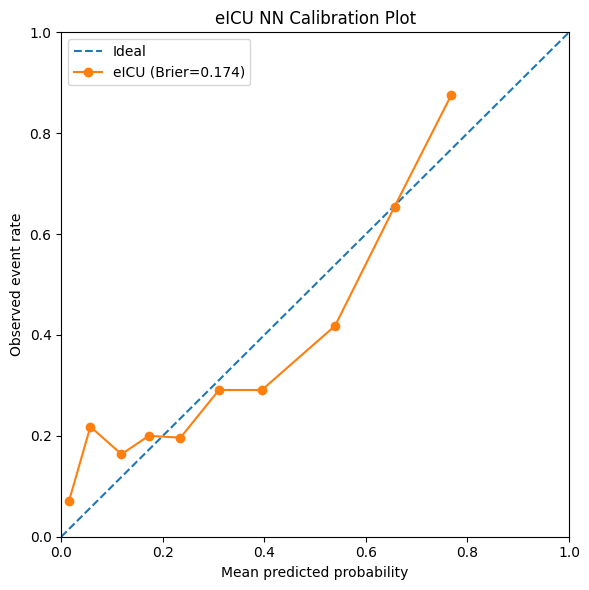

In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, probs_test),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"eICU":probs_test}, y_test, "eICU NN Calibration Plot")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'eICU NN Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

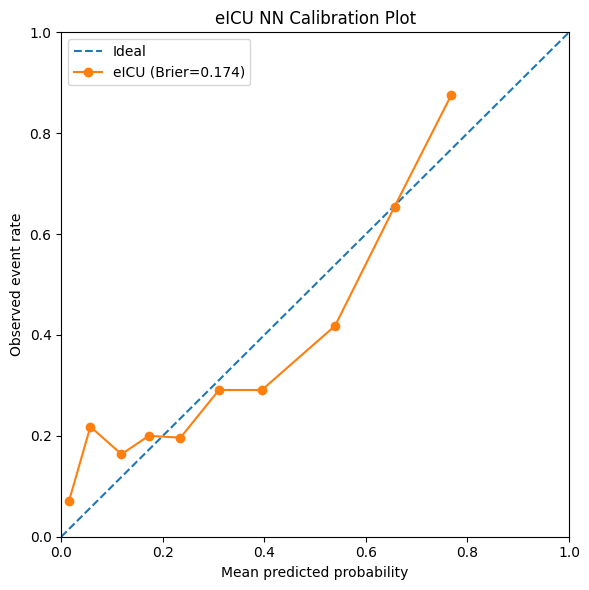

In [29]:
results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, probs_test),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"eICU":probs_test}, y_test, "eICU NN Calibration Plot")

In [30]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,553,0.338156,0.771529,0.173716,-0.054466,0.760966


In [17]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
def missingness_table(df, treatment_col, threshold=30.0, exclude_cols=None, use_fisher_if_small=True):
    """
    Create a missingness summary table for one dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Pre-imputation dataframe.
    treatment_col : str
        Name of binary treatment column (0/1).
    threshold : float
        Percent missing threshold to flag, default 30.
    exclude_cols : list or None
        Columns to exclude from the missingness table.
    use_fisher_if_small : bool
        Use Fisher's exact test when expected cell counts are small.

    Returns
    -------
    pd.DataFrame
    """
    if exclude_cols is None:
        exclude_cols = []

    cols = [c for c in df.columns if c not in exclude_cols and c != treatment_col]

    rows = []

    treat = df[treatment_col]

    for col in cols:
        miss = df[col].isna().astype(int)

        n_total = len(df)
        n_missing = miss.sum()
        pct_missing = 100 * n_missing / n_total

        miss_ttm = miss[treat == 1]
        miss_nottm = miss[treat == 0]

        n_ttm = (treat == 1).sum()
        n_nottm = (treat == 0).sum()

        pct_missing_ttm = 100 * miss_ttm.mean() if n_ttm > 0 else np.nan
        pct_missing_nottm = 100 * miss_nottm.mean() if n_nottm > 0 else np.nan

        # contingency table:
        # rows = treatment group
        # cols = missing / not missing
        table = np.array([
            [miss_nottm.sum(), (treat == 0).sum() - miss_nottm.sum()],
            [miss_ttm.sum(), (treat == 1).sum() - miss_ttm.sum()]
        ])

        # default p-value
        pval = np.nan
        test_used = None

        try:
            chi2, p_chi, dof, expected = chi2_contingency(table, correction=False)

            if use_fisher_if_small and (expected < 5).any():
                _, pval = fisher_exact(table)
                test_used = "Fisher"
            else:
                pval = p_chi
                test_used = "Chi-square"
        except Exception:
            pval = np.nan
            test_used = "Failed"

        rows.append({
            "variable": col,
            "n_missing": int(n_missing),
            "pct_missing": pct_missing,
            "pct_missing_no_ttm": pct_missing_nottm,
            "pct_missing_ttm": pct_missing_ttm,
            "abs_diff_pct": abs(pct_missing_ttm - pct_missing_nottm),
            "p_value": pval,
            "test": test_used,
            "flag_gt_30pct": pct_missing > threshold
        })

    out = pd.DataFrame(rows).sort_values(
        ["flag_gt_30pct", "pct_missing"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out
miss_eicu = missingness_table(
    df=pd.concat([X_train, X_test]),
    treatment_col="Hypothermia",
    exclude_cols=["patient_id"]
)
def missingness_summary_stats(miss_df):
    return {
        "n_variables": len(miss_df),
        "n_gt_30pct": int(miss_df["flag_gt_30pct"].sum()),
        "max_pct_missing": miss_df["pct_missing"].max(),
        "median_pct_missing": miss_df["pct_missing"].median(),
        "n_p_lt_005": int((miss_df["p_value"] < 0.05).sum())
    }

In [18]:
print("eICU:", missingness_summary_stats(miss_eicu))

eICU: {'n_variables': 36, 'n_gt_30pct': 5, 'max_pct_missing': np.float64(99.728555917481), 'median_pct_missing': np.float64(7.6547231270358305), 'n_p_lt_005': 29}


In [19]:
miss_eicu = miss_eicu.rename(columns={
    "variable": "Variable",
    "n_missing": "Missing, n",
    "pct_missing": "Missing, %",
    "pct_missing_no_ttm": "Missing in No-TTM Group, %",
    "pct_missing_ttm": "Missing in TTM Group, %",
    "abs_diff_pct": "Absolute Difference, %",
    "p_value": "P Value",
    "test": "Statistical Test"
}).drop(columns=["flag_gt_30pct"])

In [20]:
miss_eicu

,Variable,"Missing, n","Missing, %","Missing in No-TTM Group, %","Missing in TTM Group, %","Absolute Difference, %",P Value,Statistical Test
0,nurse_first_QTc,1837,99.728556,99.756888,99.671053,0.085836,6.673924e-01,Fisher
1,lab_first_troponin - T,1531,83.116178,83.792545,81.743421,2.049124,2.696092e-01,Chi-square
2,lab_first_Respiratory Rate,1497,81.270358,81.280389,81.250000,0.030389,9.874578e-01,Chi-square
3,lab_first_troponin - I,947,51.411509,54.132901,45.888158,8.244743,8.708403e-04,Chi-square
4,lab_first_lactate,559,30.347448,35.008104,20.888158,14.119946,5.710014e-10,Chi-square
5,lab_first_magnesium,529,28.718784,34.116694,17.763158,16.353536,2.993920e-13,Chi-square
6,lab_first_FiO2,389,21.118350,21.961102,19.407895,2.553207,2.067676e-01,Chi-square
7,nurse_first_GCS Total,352,19.109663,17.017828,23.355263,6.337435,1.141358e-03,Chi-square
8,lab_first_pH,320,17.372421,19.286872,13.486842,5.800030,2.004270e-03,Chi-square
9,nurse_first_Motor,310,16.829533,15.397083,19.736842,4.339759,1.922989e-02,Chi-square


In [21]:
miss_eicu.to_csv('table.csv')

In [141]:
miss_eicu[miss_eicu["flag_gt_30pct"]]

,variable,n_missing,pct_missing,pct_missing_no_ttm,pct_missing_ttm,abs_diff_pct,p_value,test,flag_gt_30pct
0,nurse_first_QTc,1287,99.844841,99.768519,100.000000,0.231481,1.000000,Fisher,True
1,lab_first_troponin - T,1075,83.397983,83.680556,82.823529,0.857026,0.697467,Chi-square,True
2,lab_first_Respiratory Rate,1044,80.993018,81.365741,80.235294,1.130447,0.626762,Chi-square,True
3,lab_first_troponin - I,673,52.211016,55.555556,45.411765,10.143791,0.000609,Chi-square,True
4,lab_first_lactate,395,30.643910,34.953704,21.882353,13.071351,0.000002,Chi-square,True


In [95]:
miss_eicu[miss_eicu["p_value"] < 0.05]

,variable,n_missing,pct_missing,pct_missing_no_ttm,pct_missing_ttm,abs_diff_pct,p_value,test,flag_gt_30pct
3,lab_first_troponin - I,665,51.590380,54.166667,46.352941,7.813725,8.316076e-03,Chi-square,True
4,lab_first_lactate,400,31.031808,35.069444,22.823529,12.245915,7.904928e-06,Chi-square,True
5,lab_first_magnesium,363,28.161365,32.407407,19.529412,12.877996,1.348638e-06,Chi-square,False
10,lab_first_paO2,206,15.981381,17.476852,12.941176,4.535675,3.669323e-02,Chi-square,False
11,lab_first_paCO2,199,15.438324,17.013889,12.235294,4.778595,2.560001e-02,Chi-square,False
12,lab_first_bicarbonate,153,11.869666,16.203704,3.058824,13.144880,6.904787e-12,Chi-square,False
13,lab_first_calcium,128,9.930178,12.962963,3.764706,9.198257,2.090171e-07,Chi-square,False
14,lab_first_platelets x 1000,117,9.076804,10.648148,5.882353,4.765795,5.110424e-03,Chi-square,False
15,lab_first_WBC x 1000,116,8.999224,10.416667,6.117647,4.299020,1.122764e-02,Chi-square,False
16,nurse_first_O2 Saturation,107,8.301009,9.375000,6.117647,3.257353,4.629427e-02,Chi-square,False


In [142]:
import numpy as np
from sklearn.metrics import brier_score_loss

event_rate = np.mean(y_test)
brier_null = event_rate * (1 - event_rate)
brier_model = brier_score_loss(y_test, probs_test)

print("Event rate:", event_rate)
print("Null Brier:", brier_null)
print("Model Brier:", brier_model)
print("Improvement:", brier_null - brier_model)

Event rate: 0.5424954792043399
Null Brier: 0.2481941342471935
Model Brier: 0.2123362717102325
Improvement: 0.035857862536960994


In [35]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(64, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")],
             jit_compile=False)


In [17]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15


2025-12-21 14:52:07.934005: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:188] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2025-12-21 14:52:08.042194: W external/local_xla/xla/service/gpu/llvm_gpu_backend/nvptx_backend.cc:110] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2025-12-21 14:52:08.048248: W external/local_xla/xla/service/gpu/llvm_gpu_backend/nvptx_backend.cc:110] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2025-12-21 14:52:08.053897: W external/local_xla/xla/service/gpu/llvm_gpu_backend/nvptx_backend.cc:110] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2025-12-21 14:52:08.059546: W external/local_xla/xla/service/gpu/llvm_gpu_backend/nvptx_backend.cc:110] libdevice is required by this HLO module but was not found at ./libdevice.10.bc
2025-12-21 14:52:08.065554: W external/local_xla/xla/service/gpu/l

UnknownError: Graph execution error:

Detected at node adam/Pow_9 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/mbranda1/.local/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/mbranda1/.local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/mbranda1/.local/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/mbranda1/.local/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/cm/local/apps/python311/lib/python3.11/asyncio/base_events.py", line 607, in run_forever

  File "/cm/local/apps/python311/lib/python3.11/asyncio/base_events.py", line 1922, in _run_once

  File "/cm/local/apps/python311/lib/python3.11/asyncio/events.py", line 80, in _run

  File "/home/mbranda1/.local/lib/python3.11/site-packages/ipykern

In [ ]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

NameError: name 'y_pred_probs' is not defined

In [ ]:
y_pred_probs.T[0, :]

In [39]:
X_train_transf.columns

Index(['num__age', 'num__bmi', 'num__hypothermia_time', 'num__lab_first_BUN',
       'num__lab_first_FiO2', 'num__lab_first_Hgb',
       'num__lab_first_Respiratory Rate', 'num__lab_first_WBC x 1000',
       'num__lab_first_bicarbonate', 'num__lab_first_calcium',
       'num__lab_first_creatinine', 'num__lab_first_glucose',
       'num__lab_first_lactate', 'num__lab_first_magnesium',
       'num__lab_first_pH', 'num__lab_first_paCO2', 'num__lab_first_paO2',
       'num__lab_first_platelets x 1000', 'num__lab_first_potassium',
       'num__lab_first_sodium', 'num__lab_first_troponin - I',
       'num__lab_first_troponin - T', 'num__nurse_first_GCS Total',
       'num__nurse_first_Heart Rate',
       'num__nurse_first_Non-Invasive BP Diastolic',
       'num__nurse_first_Non-Invasive BP Mean',
       'num__nurse_first_Non-Invasive BP Systolic',
       'num__nurse_first_O2 Saturation',
       'bin__diagnosis_initial rhythm: asystole',
       'bin__diagnosis_initial rhythm: pulseless electr

Optimization terminated successfully.
         Current function value: 0.686440
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.686435
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 0.014363753462021123
p-value: 0.9046028622281247
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1289
Model:                          Logit   Df Residuals:                     1286
Method:                           MLE   Df Model:                            2
Date:                Sun, 21 Dec 2025   Pseudo R-squ.:                0.004343
Time:                        15:04:22   Log-Likelihood:                -884.82
converged:                       True   LL-Null:                       -888.68
Covariance Type:            nonrobust   LLR p-value:                   0.02107
                    

0.9046028622281247

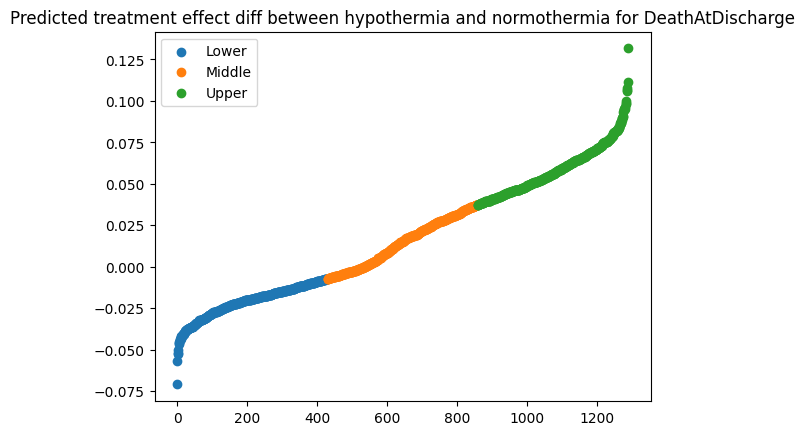

In [80]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model_torch, \
                       aCategory = 'DeathAtDischarge', aGroup = 'bin__Hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [30]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model_torch, \
                       aCategory = 'DeathAtDischarge', aGroup = 'keep__keep__bin__treatment_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

AttributeError: 'MLPBinary' object has no attribute 'predict'

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined

In [57]:
pip install shap


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
y_test.sum()

209

/home/mbranda1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 10/10 [00:02<00:00,  3.68it/s]


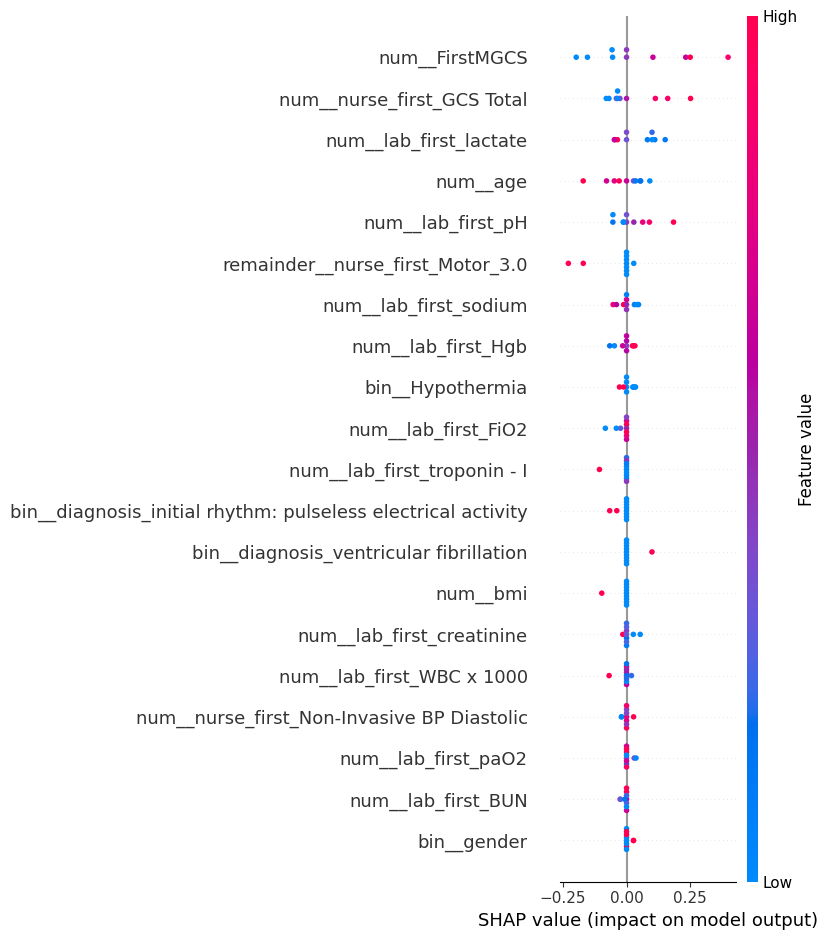

In [25]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model_torch.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [26]:
shap_values

array([[ 0.24984682,  0.0913428 ,  0.        ,  0.        ,  0.        ,
         0.03289805,  0.        ,  0.        ,  0.        ,  0.        ,
         0.02658082,  0.        ,  0.08191178,  0.        ,  0.02855646,
         0.        ,  0.        ,  0.02532996,  0.        ,  0.0307583 ,
         0.        ,  0.        ,  0.1130875 ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.09968751,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.10346627, -0.07859759,  0.        , -0.02381719, -0.08304413,
         0.        ,  0.        , -0.06837373,  0.        ,  0.        ,
         0.        ,  0.        ,  0.11082997,  0.        , -0.05362993,
         0.        ,  0.        ,  0.        ,  0.        , -0.03975316,
         0.        ,  0.     

In [27]:
feature_name = "bin__Hypothermia"
feature_index = X_explain.columns.get_loc(feature_name)

# Mean absolute SHAP value for this feature
importance_score = np.abs(shap_values[:, feature_index]).mean()
print(f"Mean |SHAP| for {feature_name}: {importance_score:.4f}")


Mean |SHAP| for bin__Hypothermia: 0.0158


In [28]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "bin__Hypothermia"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'bin__Hypothermia' is ranked #29 out of 46 in importance with mean(|SHAP|) = 0.0170


In [28]:
shap_values

[array([[ 0.00260784,  0.        , -0.28369695, ...,  0.00245607,
          0.        ,  0.        ],
        [ 0.00102849,  0.00144985, -0.01620795, ...,  0.00774075,
          0.        ,  0.        ],
        [ 0.00140487,  0.        ,  0.00691172, ...,  0.00461957,
         -0.00180843,  0.0014207 ],
        ...,
        [-0.00919301,  0.        ,  0.05207853, ...,  0.        ,
          0.0013905 , -0.00229487],
        [ 0.00184096, -0.00224829,  0.23106563, ...,  0.00066136,
         -0.00035774, -0.00135713],
        [-0.00708724,  0.00138524,  0.03438432, ...,  0.00383549,
         -0.00189342,  0.0015906 ]])]

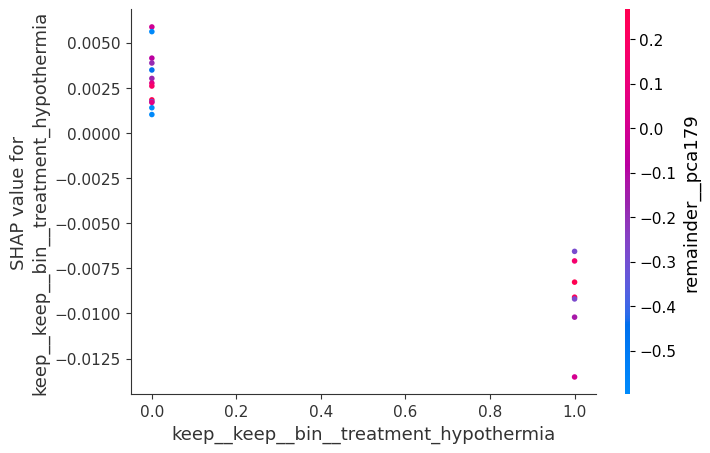

In [29]:
# Assume: shap_values = explainer.shap_values(X_explain_df)
# For binary classification: shap_values[1] = class 1 SHAP values
shap_values_class1 = shap_values[0]

# Plot interaction of 'feature_x' (you choose the name)
shap.dependence_plot("keep__keep__bin__treatment_hypothermia", shap_values_class1, X_explain)


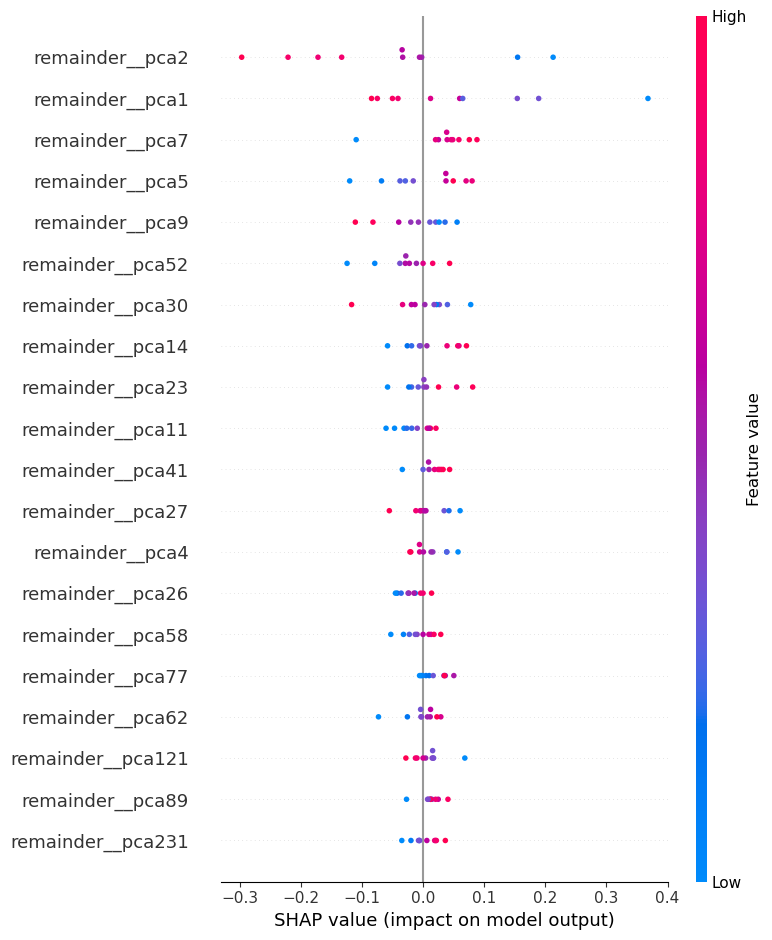

In [66]:
shap.summary_plot(shap_values[0], X_explain)